# HOM-Only Dataset Validation

This notebook checks whether the generated dataset is structurally valid before model training. It only reads generated CSV files.

In [2]:

from pathlib import Path
import json
import configparser

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4)
pd.set_option('display.max_columns', 120)


def find_package_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for root in candidates:
        p = root / 'example' / 'hom_validation' / 'ai_hom_dataset'
        if (p / 'configs' / 'hom_ai_dataset_config.ini').exists():
            return p
        if (root / 'configs' / 'hom_ai_dataset_config.ini').exists():
            return root
    raise FileNotFoundError('Could not locate ai_hom_dataset package directory')

PACKAGE_DIR = find_package_dir()
CONFIG_PATH = PACKAGE_DIR / 'configs' / 'hom_ai_dataset_config.ini'

parser = configparser.ConfigParser(inline_comment_prefixes=('#', ';'), interpolation=None)
parser.read(CONFIG_PATH, encoding='utf-8-sig')
DATASET_NAME = parser.get('generation', 'dataset_name', fallback='hom_ai_dataset_sample')
configured_output = parser.get('slurm', 'output_dir', fallback='').strip()
DATASET_DIR = Path(configured_output) if configured_output else PACKAGE_DIR / 'generated' / DATASET_NAME

SAVE_PLOTS = True
PLOTS_DIR = PACKAGE_DIR.parent / 'plots' / 'hom_dataset_validation' / DATASET_NAME

def save_pdf(fig, name: str) -> Path | None:
    if not SAVE_PLOTS:
        return None
    path = PLOTS_DIR / f'{name}.pdf'
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, format='pdf', bbox_inches='tight')
    print('Saved plot:', path)
    return path

print(f'Package dir: {PACKAGE_DIR}')
print(f'Dataset dir: {DATASET_DIR}')
print(f'PDF output: {PLOTS_DIR}')


def require_file(name: str) -> Path:
    path = DATASET_DIR / name
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}. Generate the dataset first, or update DATASET_DIR.')
    return path


def load_csv(name: str) -> pd.DataFrame:
    return pd.read_csv(require_file(name))


Package dir: c:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-ai-dataset\example\hom_validation\ai_hom_dataset
Dataset dir: c:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-ai-dataset\example\hom_validation\ai_hom_dataset\generated\hom_ai_dataset_60s_10k_blackbird


In [3]:

observable = load_csv('hom_observable_windows.csv')
labels = load_csv('episode_labels.csv')
truth = load_csv('hidden_truth.csv')
summary = load_csv('validation_summary.csv')
setup = load_csv('setup_params.csv')
metadata = json.loads(require_file('metadata.json').read_text(encoding='utf-8'))

print('Dataset:', metadata.get('dataset_name'))
print('Episodes:', len(labels), 'Windows:', len(observable))
print('Window duration:', metadata.get('window_duration_s'))
print('Episode duration:', metadata.get('episode_duration_s'))


Dataset: hom_ai_dataset_60s_10k_blackbird
Episodes: 10000 Windows: 600000
Window duration: 1.0
Episode duration: 60.0


## Structural Checks

In [4]:

checks = []

def add_check(name, ok, detail=''):
    checks.append({'check': name, 'ok': bool(ok), 'detail': detail})

is_partial = bool(metadata.get('partial', False))

add_check('required observable columns', {'episode_id', 'window_index', 'fault_class'}.issubset(observable.columns), str(observable.columns[:10].tolist()))
add_check('required label columns', {'episode_id', 'fault_class', 'fault_onset_window'}.issubset(labels.columns), str(labels.columns.tolist()))
add_check('required truth columns', {'episode_id', 'window_index', 'fault_class'}.issubset(truth.columns), str(truth.columns[:10].tolist()))
add_check('episode ids match labels/observable', set(labels['episode_id']) == set(observable['episode_id']), '')
add_check('episode ids match labels/truth', set(labels['episode_id']) == set(truth['episode_id']), '')
add_check('no duplicate label rows', labels['episode_id'].is_unique, '')
add_check('no duplicate observable rows', not observable.duplicated(['episode_id', 'window_index']).any(), '')
add_check('no duplicate truth rows', not truth.duplicated(['episode_id', 'window_index']).any(), '')

windows_by_ep = observable.groupby('episode_id')['window_index'].nunique()
if 'episode_duration_s' in metadata and 'window_duration_s' in metadata:
    expected_windows = int(round(float(metadata['episode_duration_s']) / float(metadata['window_duration_s'])))
else:
    expected_windows = int(windows_by_ep.mode().iloc[0])
add_check('all episodes have expected windows', (windows_by_ep == expected_windows).all(), windows_by_ep.describe().to_string())

counts = labels['fault_class'].value_counts().sort_index()
expected_size = metadata.get('dataset_size')
if expected_size is not None:
    add_check('dataset size matches metadata', len(labels) == int(expected_size), f"labels={len(labels)} metadata={expected_size}")
if is_partial:
    print('Partial dataset detected: class imbalance is allowed for temporary review.')
else:
    add_check('all fault classes present', set(counts.index) == set(labels['fault_class'].unique()) and (counts > 0).all(), counts.to_string())
print('Fault class counts; exact balance is not expected because labels are sampled randomly:')
print(counts.to_string())

check_df = pd.DataFrame(checks)
check_df


Fault class counts; exact balance is not expected because labels are sampled randomly:
fault_class
attenuation_loss          1103
healthy                   1081
polarization_drift        1104
raman_noise               1147
source_brightness_loss    1097
source_clock_drift        1081
spectral_detuning         1132
sync_issue                1142
temperature_drift         1113


,check,ok,detail
0,required observable columns,True,"['episode_id', 'setup_id', 'fault_class', 'win..."
1,required label columns,True,"['episode_id', 'setup_id', 'fault_class', 'see..."
2,required truth columns,True,"['episode_id', 'window_index', 'seed', 'fault_..."
3,episode ids match labels/observable,True,
4,episode ids match labels/truth,True,
5,no duplicate label rows,True,
6,no duplicate observable rows,True,
7,no duplicate truth rows,True,
8,all episodes have expected windows,True,count 10000.0\nmean 60.0\nstd ...
9,dataset size matches metadata,True,labels=10000 metadata=10000


In [5]:

if not check_df['ok'].all():
    raise RuntimeError('Dataset validation failed. See failed checks above.')
print('All structural checks passed.')


All structural checks passed.


## AI Input Leakage Check

These columns are allowed for bookkeeping but must be excluded from model features. Hidden truth must not be used as operational input.

In [6]:

bookkeeping_cols = {'episode_id', 'setup_id', 'fault_class', 'window_index', 'window_start_s', 'window_end_s', 'window_duration_s', 'fault_active'}
truth_like_patterns = ['true_', 'sim_', 'faulty_', 'target_fault', 'fault_onset']
leakage_like = [c for c in observable.columns if any(c.startswith(p) for p in truth_like_patterns)]
print('Bookkeeping columns in observable:', sorted(bookkeeping_cols & set(observable.columns)))
print('Truth-like columns found in observable:', leakage_like)
if leakage_like:
    raise RuntimeError('Observable table contains truth-like columns.')

feature_cols = [c for c in observable.columns if c not in bookkeeping_cols]
print('Candidate AI feature count:', len(feature_cols))
feature_cols[:30]


Bookkeeping columns in observable: ['episode_id', 'fault_active', 'fault_class', 'setup_id', 'window_duration_s', 'window_end_s', 'window_index', 'window_start_s']
Truth-like columns found in observable: []
Candidate AI feature count: 31


['hom1_count',
 'hom2_count',
 'hom1_rate_hz',
 'hom2_rate_hz',
 'hom_singles_sum_rate_hz',
 'hom_twofold_count',
 'hom_twofold_rate_hz',
 'peak_position_ps',
 'peak_width_ps',
 'peak_height',
 'peak_snr',
 'coincidence_count_hist',
 'accidental_count_estimate',
 'accidental_rate_hz',
 'car',
 'hom1_interarrival_mean_ps',
 'hom1_interarrival_std_ps',
 'hom1_interarrival_min_ps',
 'hom1_interarrival_max_ps',
 'hom2_interarrival_mean_ps',
 'hom2_interarrival_std_ps',
 'hom2_interarrival_min_ps',
 'hom2_interarrival_max_ps',
 'delta_hom1_rate_hz',
 'delta_hom2_rate_hz',
 'delta_hom_twofold_rate_hz',
 'delta_peak_position_ps',
 'delta_peak_width_ps',
 'delta_peak_snr',
 'delta_car']

## Baseline Imperfection Checks

Healthy should include normal imperfections, not perfect zeros. Faults should add deviations above the same baseline.

In [7]:

cols = [c for c in ['sim_attenuation_db_per_m_signal_a', 'sim_attenuation_db_per_m_signal_b', 'sim_raman_power_mw_a', 'sim_raman_power_mw_b', 'sim_raman_noise_rate_total_hz'] if c in truth.columns]
baseline = truth.groupby('fault_class')[cols].agg(['mean', 'min', 'max'])
baseline


sim_attenuation_db_per_m_signal_a                    \
                                                    mean     min       max   
fault_class                                                                  
attenuation_loss                                0.000229  0.0002  0.000399   
healthy                                         0.000200  0.0002  0.000200   
polarization_drift                              0.000200  0.0002  0.000200   
raman_noise                                     0.000200  0.0002  0.000200   
source_brightness_loss                          0.000200  0.0002  0.000200   
source_clock_drift                              0.000200  0.0002  0.000200   
spectral_detuning                               0.000200  0.0002  0.000200   
sync_issue                                      0.000200  0.0002  0.000200   
temperature_drift                               0.000200  0.0002  0.000200   

                       sim_attenuation_db_per_m_signal_b                  \
                                                    mean     min     max   
fault_class                                                                
attenuation_loss                                0.000229  0.0002  0.0004   
healthy                                         0.000200  0.0002  0.0002   
polarization_drift                              0.000200  0.0002  0.0002   
raman_noise                                     0.000200  0.0002  0.0002   
source_brightness_loss                          0.000200  0.0002  0.0002   
source_clock_drift                              0.000200  0.0002  0.0002   
spectral_detuning                               0.000200  0.0002  0.0002   
sync_issue                                      0.000200  0.0002  0.0002   
temperature_drift                               0.000200  0.0002  0.0002   

                       sim_raman_power_mw_a                  \
                                       mean   min       max   
fault_class                                                   
attenuation_loss                   0.020000  0.02  0.020000   
healthy                            0.020000  0.02  0.020000   
polarization_drift                 0.020000  0.02  0.020000   
raman_noise                        0.089984  0.02  0.519398   
source_brightness_loss             0.020000  0.02  0.020000   
source_clock_drift                 0.020000  0.02  0.020000   
spectral_detuning                  0.020000  0.02  0.020000   
sync_issue                         0.020000  0.02  0.020000   
temperature_drift                  0.020000  0.02  0.020000   

                       sim_raman_power_mw_b                  \
                                       mean   min       max   
fault_class                                                   
attenuation_loss                   0.020000  0.02  0.020000   
healthy                            0.020000  0.02  0.020000   
polarization_drift                 0.020000  0.02  0.020000   
raman_noise                        0.087943  0.02  0.519265   
source_brightness_loss             0.020000  0.02  0.020000   
source_clock_drift                 0.020000  0.02  0.020000   
spectral_detuning                  0.020000  0.02  0.020000   
sync_issue                         0.020000  0.02  0.020000   
temperature_drift                  0.020000  0.02  0.020000   

                       sim_raman_noise_rate_total_hz                 \
                                                mean            min   
fault_class                                                           
attenuation_loss                       214187.316437  214187.316437   
healthy                                214187.316437  214187.316437   
polarization_drift                     214187.316437  214187.316437   
raman_noise                            952742.620254  214187.316437   
source_brightness_loss                 214187.316437  214187.316437   
source_clock_drift                     214187.316437  214187.316437   
spectral_detuning   

In [8]:

if {'sim_raman_power_mw_a', 'sim_raman_power_mw_b'}.issubset(truth.columns):
    healthy = truth[truth['fault_class'] == 'healthy']
    assert (healthy['sim_raman_power_mw_a'] > 0).all()
    assert (healthy['sim_raman_power_mw_b'] > 0).all()
    print('Healthy Raman baseline present on both HOM arms.')


Healthy Raman baseline present on both HOM arms.


## Fault Truth Sanity

Uses hidden truth only to check that each fault actually injects the intended physical variable.

In [9]:

fault_truth_map = {
    'temperature_change': ['true_temperature_shift_c'],
    'polarization_drift': ['true_polarization_twist_rad_per_m', 'true_polarization_bend_radius_m'],
    'spectral_detuning': ['true_spectral_detuning_nm'],
    'raman_noise': ['true_raman_power_mw'],
    'attenuation_loss': ['true_extra_loss_db_per_m_a', 'true_extra_loss_db_per_m_b'],
    'source_brightness_loss': ['true_source_brightness_factor_a', 'true_source_brightness_factor_b'],
    'sync_issue': ['true_sync_jitter_ps'],
    'source_clock_drift': ['true_source_clock_drift_ps_per_s', 'true_source_clock_offset_ps'],
}
rows = []
for fault, cols in fault_truth_map.items():
    if fault not in truth['fault_class'].unique():
        continue
    sub = truth[truth['fault_class'] == fault]
    row = {'fault_class': fault, 'windows': len(sub)}
    for col in cols:
        if col in sub.columns:
            row[f'{col}_abs_max'] = float(sub[col].abs().max())
    rows.append(row)
fault_truth = pd.DataFrame(rows)
fault_truth


,fault_class,windows,true_temperature_shift_c_abs_max,true_polarization_twist_rad_per_m_abs_max,true_polarization_bend_radius_m_abs_max,true_spectral_detuning_nm_abs_max,true_raman_power_mw_abs_max,true_extra_loss_db_per_m_a_abs_max,true_extra_loss_db_per_m_b_abs_max,true_source_brightness_factor_a_abs_max,true_source_brightness_factor_b_abs_max,true_sync_jitter_ps_abs_max,true_source_clock_drift_ps_per_s_abs_max,true_source_clock_offset_ps_abs_max
0,temperature_drift,66780,39.995305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,polarization_drift,66240,NaN,0.19964,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,spectral_detuning,67920,NaN,NaN,NaN,0.398842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,raman_noise,68820,NaN,NaN,NaN,NaN,0.499398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,attenuation_loss,66180,NaN,NaN,NaN,NaN,NaN,0.000199,0.0002,NaN,NaN,NaN,NaN,NaN
5,source_brightness_loss,65820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
6,sync_issue,68520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11975.301034,NaN,NaN
7,source_clock_drift,64860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1997.520229,117681.401426


## Missing/Finite Value Checks

In [10]:

numeric_features = observable[feature_cols].select_dtypes(include=[np.number])
delta_cols = [c for c in numeric_features.columns if c.startswith('delta_')]
non_delta_cols = [c for c in numeric_features.columns if c not in delta_cols]

missing_non_delta = numeric_features[non_delta_cols].isna().sum().sort_values(ascending=False)
nonfinite_non_delta = (~np.isfinite(numeric_features[non_delta_cols])).sum().sort_values(ascending=False)
report = pd.DataFrame({'missing': missing_non_delta, 'nonfinite': nonfinite_non_delta})
report = report[(report['missing'] > 0) | (report['nonfinite'] > 0)]

bad_delta_cols = []
for col in delta_cols:
    missing_mask = observable[col].isna()
    allowed_mask = observable['window_index'].astype(int) == 0
    if (missing_mask & ~allowed_mask).any():
        bad_delta_cols.append(col)

print(f'Delta columns with first-window NaN allowed: {len(delta_cols)}')
print('Delta columns with unexpected NaN:', bad_delta_cols)
report


Delta columns with first-window NaN allowed: 8
Delta columns with unexpected NaN: []


,missing,nonfinite


In [11]:

if not report.empty or bad_delta_cols:
    raise RuntimeError('Found unexpected missing or non-finite numeric feature values.')
print('No unexpected missing/non-finite numeric feature values.')


No unexpected missing/non-finite numeric feature values.


## Quick Separability View

This is not final model training. It checks whether simple HOM-only features show class-dependent movement.

In [12]:

key_features = [c for c in ['hom_twofold_rate_hz', 'peak_position_ps', 'peak_width_ps', 'peak_snr', 'car', 'accidental_rate_hz'] if c in observable.columns]
class_means = observable.groupby('fault_class')[key_features].mean().sort_index()
class_stds = observable.groupby('fault_class')[key_features].std().sort_index()
class_means


,hom_twofold_rate_hz,peak_position_ps,peak_width_ps,peak_snr,car,accidental_rate_hz
fault_class,,,,,,
attenuation_loss,1229.687232,0.732245,99.914778,225.275342,77.518032,15.795890
healthy,1472.082069,0.914585,99.978107,249.406464,85.879099,17.269380
polarization_drift,1472.045577,0.821558,99.982790,249.462718,85.881599,17.268295
raman_noise,1611.808195,0.880558,99.991282,134.709622,46.690863,157.079849
source_brightness_loss,1170.017882,0.697356,99.860529,218.727995,75.537756,15.295092
source_clock_drift,1359.692461,0.771200,99.971014,200.401711,69.362602,21.850809
spectral_detuning,1598.308584,0.903121,99.982038,272.452525,93.198344,17.278693
sync_issue,778.986529,-341.917980,82.151781,128.570673,44.360111,30.867993
temperature_drift,1363.703444,0.874513,100.638814,200.528371,69.949916,21.695118


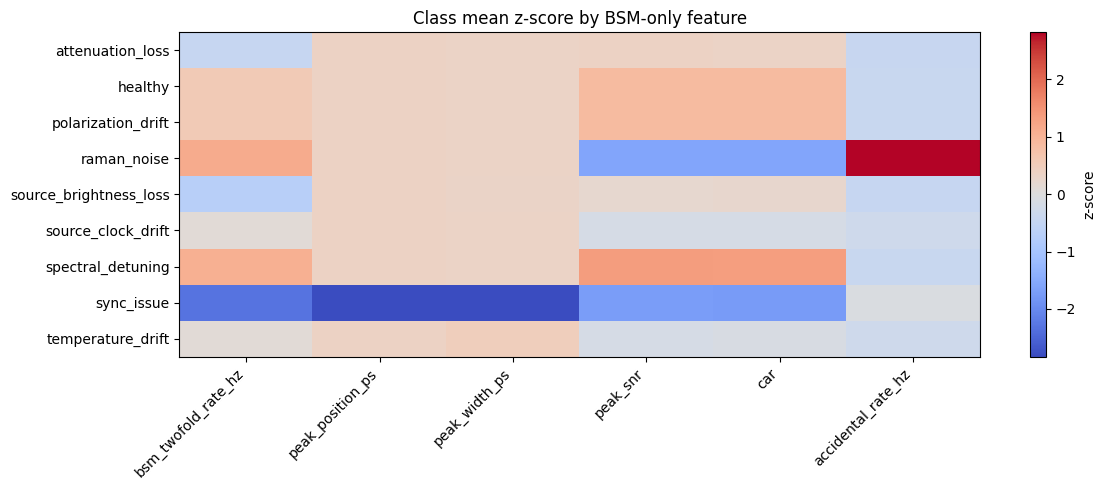

In [13]:

if key_features:
    normalized = (class_means - class_means.mean()) / class_means.std(ddof=0).replace(0, np.nan)
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(normalized.fillna(0), aspect='auto', cmap='coolwarm')
    ax.set_xticks(range(len(normalized.columns)))
    ax.set_xticklabels(normalized.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(normalized.index)))
    ax.set_yticklabels(normalized.index)
    ax.set_title('Class mean z-score by HOM-only feature')
    plt.colorbar(im, ax=ax, label='z-score')
    plt.tight_layout()
    save_pdf(fig, '01_class_mean_feature_zscores')
    plt.show()
